#### Tutorial and Lab 8

**Numpy and Pytorch tensors**  

In [1]:
import numpy as np
import torch
import pandas as pd

In [2]:
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cpu
False


**What is a tensor**?

#### Scalars, Vectors and Tensors
1. Tensors are multi-axis or rank, multidimensional objects. This means that the are numbers arranged along different axes.
2. The word dimension can be confusing in this context. So we simply use the letter **D** to represent rank. Along each axes the dimension can be different.   
    i. Scalars are rank 0 tensors. Also written 0D.   
    ii. Vectors are rank 1 tensors (1D). A vector may be of arbitrary dimension.    
    iii. Matrices are rank 2 tensors (2D). Here we have different dimension along the two axes. For example, a $2\times 3$ matrix has dimension 2 along one axis and 3 along the other.  

**Examples**
1. 1D: *tf-idf* vector of a single document
2. 2D: array of tf-idf vectors of corpora, a text represented bu sequencce of vectors representing tokens
3. 3D: a colour image
4. 4D: a video clip in AusLan...

In [3]:
import math
def basic_tanh(x):
    tup = x.shape
    y = np.zeros(x.shape)
    for i in range(tup[0]):
        for j in range(tup[1]):
            y[i,j] = math.tanh(x[i,j])
    return y

In [4]:
X = np.random.random((10000, 5000))

In [5]:
X.shape

(10000, 5000)

In [6]:
import time
t0 = time.time()
Y = basic_tanh(X)
print("time elapsed: ", time.time()-t0)

time elapsed:  24.45017957687378


In [7]:
t0 = time.time()
#X = np.random.random((10000, 10000))
Y = np.tanh(X)
print("time elapsed: ", time.time()-t0)

time elapsed:  3.192028760910034


In [8]:
tanh_v = np.vectorize(math.tanh)

In [9]:
u = tanh_v(X)

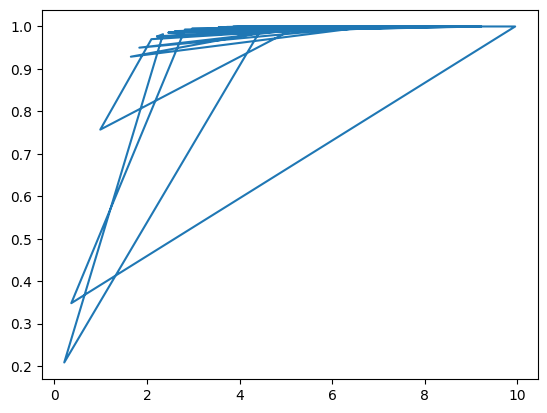

In [10]:
import matplotlib.pyplot as plt
X1 = (X[0:10,0:5].reshape((50, 1)))*10
Y1 = np.tanh(X1)

plt.plot(X1,Y1)
#why does the plot command prduce such a mess, how do we fix it?

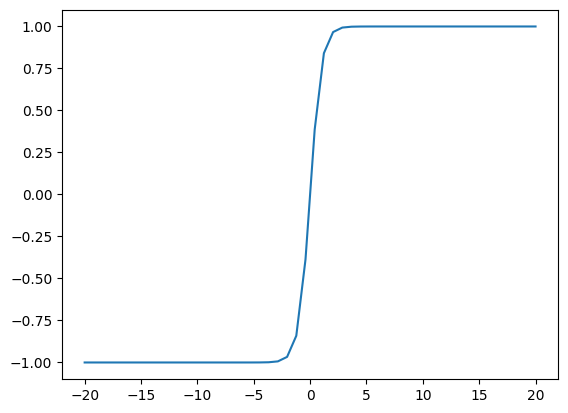

In [11]:
X2 = np.linspace(-20, 20)
Y2 = np.tanh(X2)
plt.plot(X2, Y2)

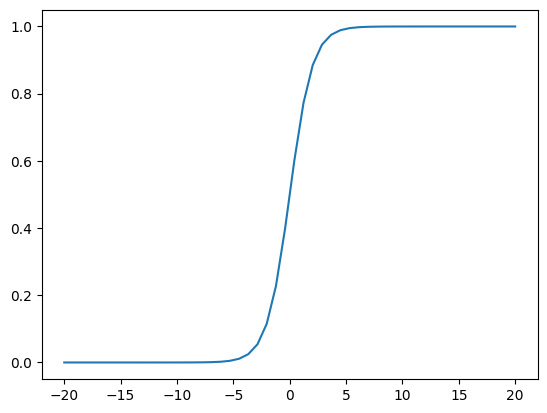

In [12]:
def sigmoid(x):
    return 1/(1+np.exp(-x))
plt.plot(X2, sigmoid(X2))

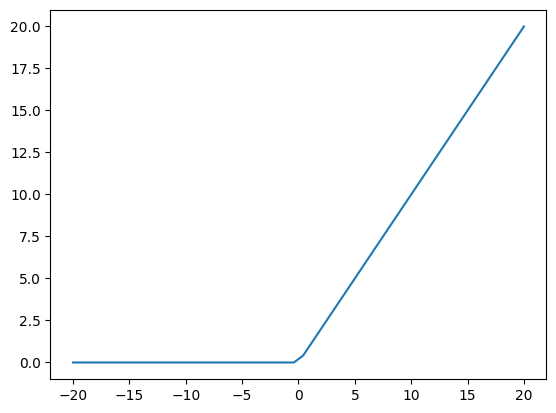

In [13]:
u = (0.5 - np.random.random((3,4)))*4
def relu(x):
    return (np.maximum(x,0))
plt.plot(X2, relu(X2))

In [14]:
z_ls = [[j for j in range(i, i+3)] for i in range(0,12,3)]
z = np.array(z_ls)
z_t = torch.tensor(z_ls)
z_t.shape, z_t.device

(torch.Size([4, 3]), device(type='cpu'))

In [17]:
z_t

tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])

In [ ]:
a = np.arange(2 * 2 * 4).reshape((2, 2, 4))
b = np.arange(2 * 2 * 4).reshape((2, 4, 2))
u = np.matmul(a,b)

In [ ]:
print(a)
print(b)

In [ ]:
u

In [18]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
z_tt = torch.tensor(z_ls, device=device)
z_tt.device

device(type='cpu')

In [ ]:
u = torch.arange(24)
v = u.reshape((2,3,4))
v.device

Try the following functions for creating torch tensors.

1. torch.zeros(\*size, out=None,dtype=None, layout=torch.strided, device=None, requires_grad=False)
2. torch.ones(...)
3. torch.arange(start=0, end, step=1,out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False)
4. torch.logspace(start, end,steps=100, base=10.0, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False)
5. torch.eye(n, m=None, out=None, dtype=None, layout=torch.strided, device=None, requires_grad=False)
6. torch.full(size, fill_value,out=None, dtype=None,layout=torch.strided, device=None,requires_grad=False)


**Finding gradients.**

Gradients are very important in ML and other areas. We minimize functions by a method called **gradient descent**.

What are the gradients of the following functions:
$$ f(x, y, z) = x^2 + y^2 + z^2, \; g(x, y, z) = \sin{(x)}y^2 - 2x^2y^{1/2}z^3+ \cos{z}(x-y)^2 $$

*Find the gradintes manually. What kind of objects are gradients?*

In [19]:
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)
z = torch.tensor(1.5, requires_grad=True)
f = x**2+y**2+z**2
f.backward()
x.grad, y.grad, z.grad

(tensor(4.), tensor(6.), tensor(3.))

$$\frac{\partial f}{\partial x}\Big | {x=2, y=3, z=1.5}$$

$$\frac{\partial f}{\partial x} = 2x ,  \frac{\partial f}{\partial x} = 2y$$

In [20]:
g = x.sin()*y*y - 2*x*x*y.sqrt()*z*z*z + (z*(x-y)*(x-y)).cos()

In [21]:
g.backward()
x.grad

tensor(-43.5182)